# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

## 2. Load Dataset

In [3]:
df = pd.read_csv("European_Bank.csv")

df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Basic Information

In [5]:
print("Dataset Shape :", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape : (10000, 14)

Columns:
Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

Data Types:
Year                 int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


## 4. Missing Values Check

In [7]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## 5. Duplicate Records Check

In [13]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


## 6. Statistical Summary

In [16]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 7. Validate Binary Columns

In [19]:
print(df['Exited'].value_counts())

print(df['HasCrCard'].value_counts())

print(df['IsActiveMember'].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64
HasCrCard
1    7055
0    2945
Name: count, dtype: int64
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64


## 8. Validate Geography

In [22]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

## 9. Validate Gender

In [25]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

## 10. Outlier / Invalid Data Checks

In [28]:
# Age
df[(df['Age'] < 18) | (df['Age'] > 100)]

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [30]:
# Credit Score
df[(df['CreditScore'] < 0) | (df['CreditScore'] > 1000)]

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [32]:
# Balance
df[df['Balance'] < 0]

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [34]:
# Salary
df[df['EstimatedSalary'] < 0]

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [36]:
# Tenure
df[(df['Tenure'] < 0) | (df['Tenure'] > 10)]

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


## 11. Remove Non-Analytical Columns

In [39]:
df.drop(
    ['Year','CustomerId','Surname'],
    axis=1,
    inplace=True
)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# 12. Customer Segmentation

## Age Segmentation

In [43]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,30,45,60,100],
    labels=['<30','30-45','46-60','60+']
)

## Credit Score Segmentation

In [46]:
df['Credit_Band'] = pd.cut(
    df['CreditScore'],
    bins=[0,500,700,1000],
    labels=['Low','Medium','High']
)

## Tenure Segmentation

In [49]:
df['Tenure_Group'] = pd.cut(
    df['Tenure'],
    bins=[-1,3,7,10],
    labels=['New','Mid-Term','Long-Term']
)

## Balance Segmentation

In [52]:
df['Balance'].describe()
df['Balance_Group'] = pd.cut(
    df['Balance'],
    bins=[-1,0,100000,300000],
    labels=['Zero Balance','Low Balance','High Balance']
)

## High Value Customer Flag

In [55]:
df['High_Value_Customer'] = np.where(
    df['Balance'] > 100000,
    1,
    0
)

## 13. Save Clean Dataset

In [58]:
df.to_csv(
    "European_Bank_Cleaned.csv",
    index=False
)

##  14. KPI 1 – Overall Churn Rate

In [61]:
overall_churn = round(
    df['Exited'].mean()*100,
    2
)

print("Overall Churn Rate :", overall_churn,"%")

Overall Churn Rate : 20.37 %


## 15. KPI 2 – Segment Churn Rate

In [64]:
age_churn = (
    df.groupby('Age_Group')['Exited']
    .mean()*100
).round(2)

age_churn

Age_Group
<30       7.52
30-45    15.74
46-60    51.12
60+      24.78
Name: Exited, dtype: float64

### Geography

In [67]:
geo_churn = (
    df.groupby('Geography')['Exited']
    .mean()*100
).round(2)

geo_churn

Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64

### Gender

In [70]:
gender_churn = (
    df.groupby('Gender')['Exited']
    .mean()*100
).round(2)

gender_churn

Gender
Female    25.07
Male      16.46
Name: Exited, dtype: float64

## 16. KPI 3 – High Value Churn Ratio

In [73]:
high_value_churn = round(
    df[df['High_Value_Customer']==1]['Exited']
    .mean()*100,
    2
)

print(high_value_churn,"%")

25.23 %


## 17. KPI 4 – Geographic Risk Index

In [76]:
geo_risk = (
    df.groupby('Geography')['Exited']
    .mean()*100
).round(2)

geo_risk

Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64

## 18. KPI 5 – Engagement Drop Indicator

In [79]:
engagement = pd.crosstab(
    df['IsActiveMember'],
    df['Exited'],
    normalize='index'
)*100

engagement

Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


## 19. Overall Churn Distribution

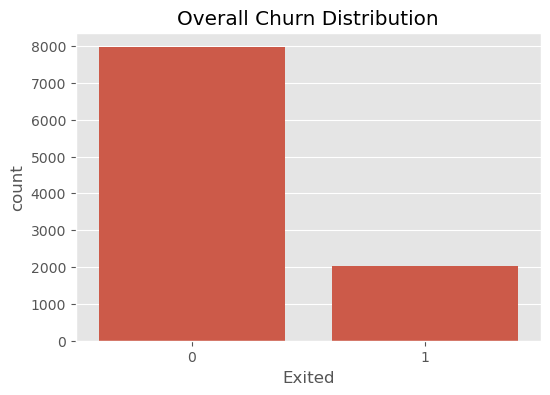

In [82]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Exited',
    data=df
)

plt.title('Overall Churn Distribution')
plt.show()

## 20. Geography-wise Churn

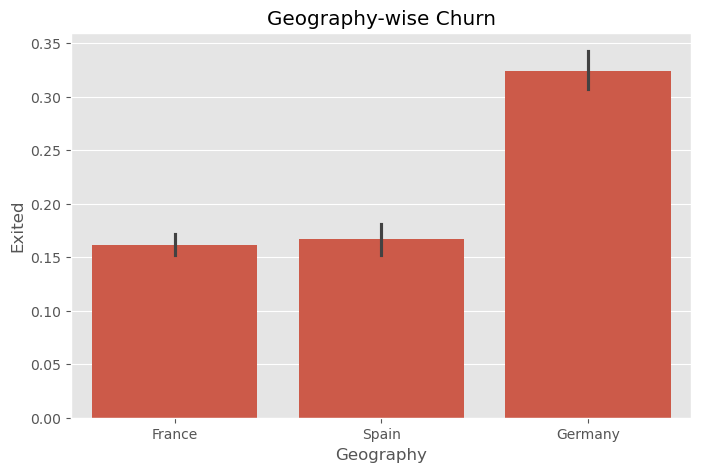

In [84]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Geography',
    y='Exited',
    data=df
)

plt.title('Geography-wise Churn')
plt.show()

## 21. Age-wise Churn

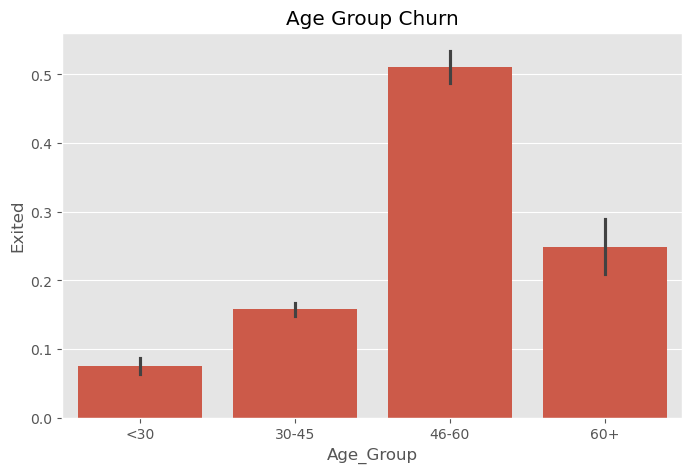

In [86]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Age_Group',
    y='Exited',
    data=df
)

plt.title('Age Group Churn')
plt.show()

## 22. Tenure-wise Churn

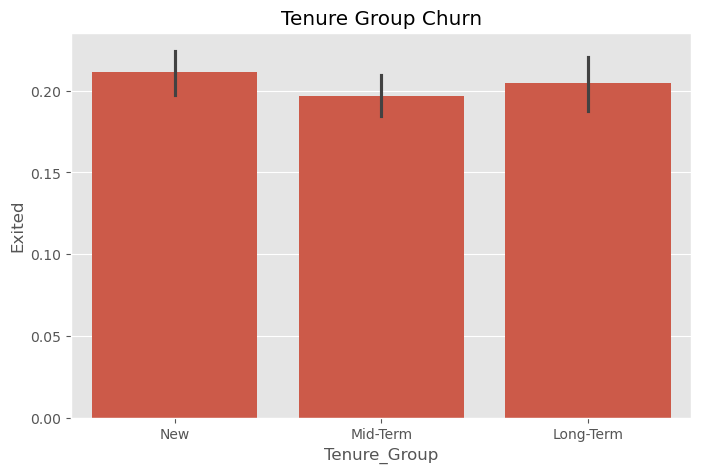

In [89]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Tenure_Group',
    y='Exited',
    data=df
)

plt.title('Tenure Group Churn')
plt.show()

## 23. Gender-wise Churn

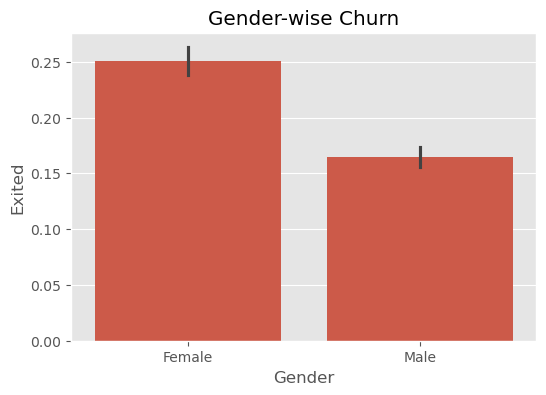

In [92]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Gender',
    y='Exited',
    data=df
)

plt.title('Gender-wise Churn')
plt.show()

## 23B Add Geography + Gender Churn Analysis

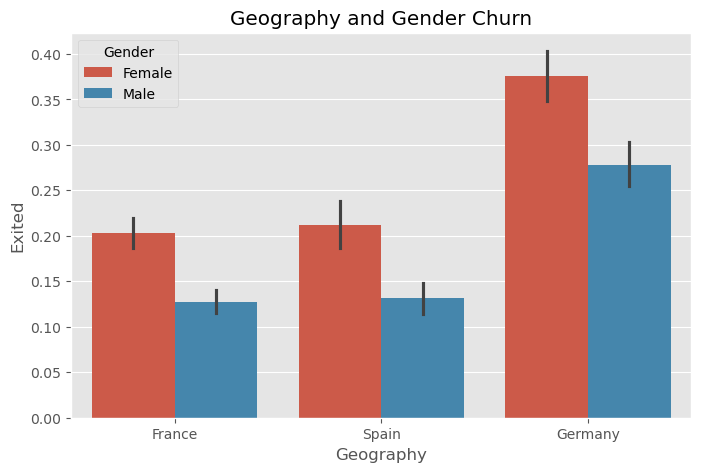

In [96]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Geography',
    y='Exited',
    hue='Gender'
)

plt.title("Geography and Gender Churn")
plt.show()

## 24. Credit Score Band Churn

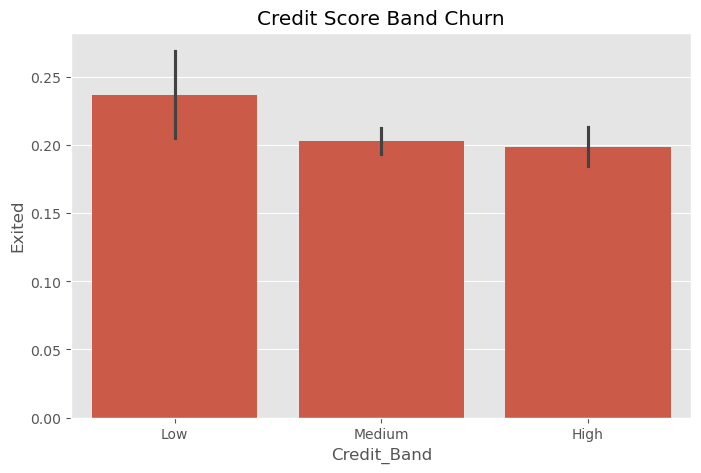

In [99]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Credit_Band',
    y='Exited',
    data=df
)

plt.title('Credit Score Band Churn')
plt.show()

## 25. Balance Segment Churn

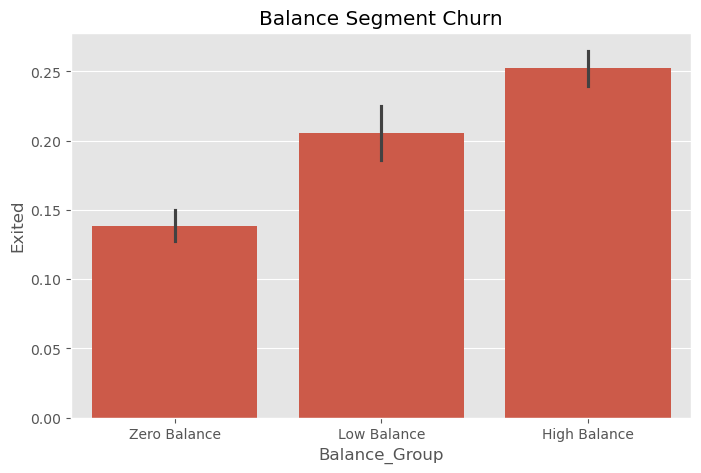

In [102]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Balance_Group',
    y='Exited',
    data=df
)

plt.title('Balance Segment Churn')
plt.show()

## 26. Active vs Inactive Churn

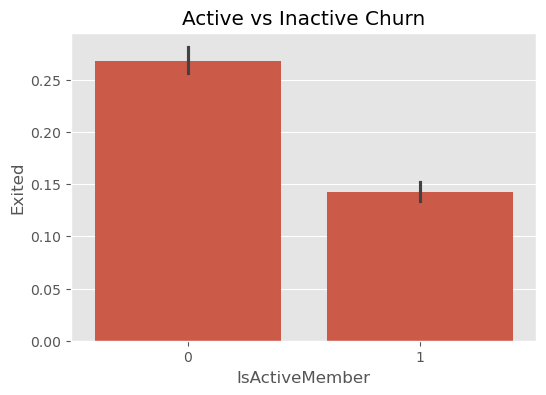

In [105]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='IsActiveMember',
    y='Exited',
    data=df
)

plt.title('Active vs Inactive Churn')
plt.show()

## 27. Churned vs Retained Balance Comparison

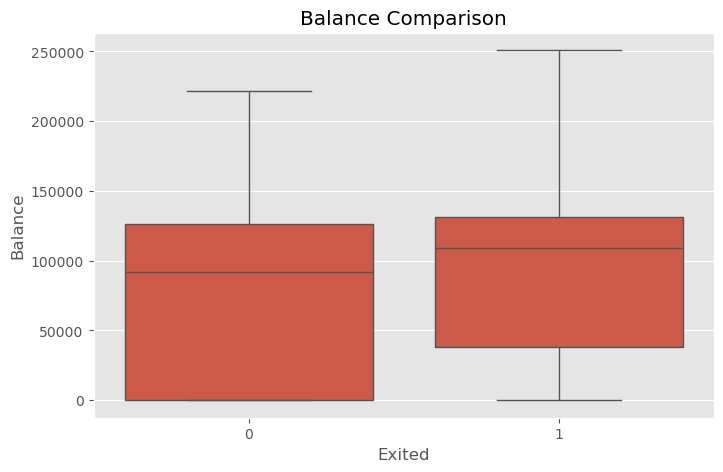

In [108]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='Balance',
    data=df
)

plt.title('Balance Comparison')
plt.show()

In [109]:
# Churned vs Retained Customer Profile Comparison

profile_comparison = df.groupby('Exited')[[
    'Age',
    'CreditScore',
    'Balance',
    'EstimatedSalary'
]].mean().round(2)

print("Churned vs Retained Customer Profiles")
print(profile_comparison)

Churned vs Retained Customer Profiles
          Age  CreditScore   Balance  EstimatedSalary
Exited                                               
0       37.41       651.85  72745.30         99738.39
1       44.84       645.35  91108.54        101465.68


## 28. Geography × Age Interaction Analysis

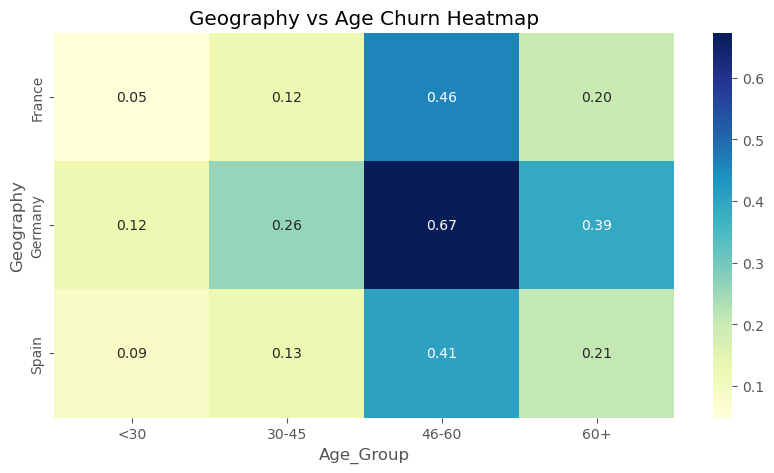

In [114]:
pivot = pd.pivot_table(
    df,
    values='Exited',
    index='Geography',
    columns='Age_Group',
    aggfunc='mean'
)

plt.figure(figsize=(10,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Geography vs Age Churn Heatmap')
plt.show()

## 29. Salary vs Balance Churn Pattern

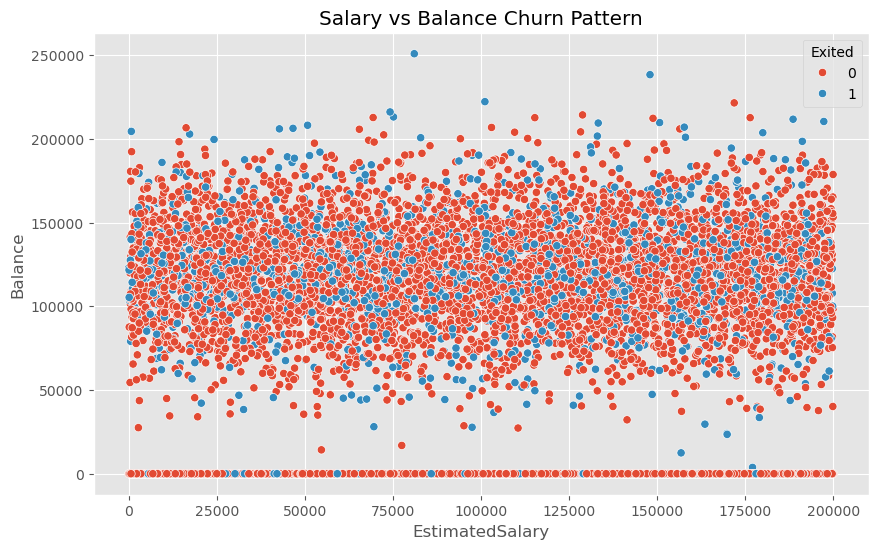

In [117]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='EstimatedSalary',
    y='Balance',
    hue='Exited'
)

plt.title('Salary vs Balance Churn Pattern')
plt.show()

## 29B Add Correlation Heatmap

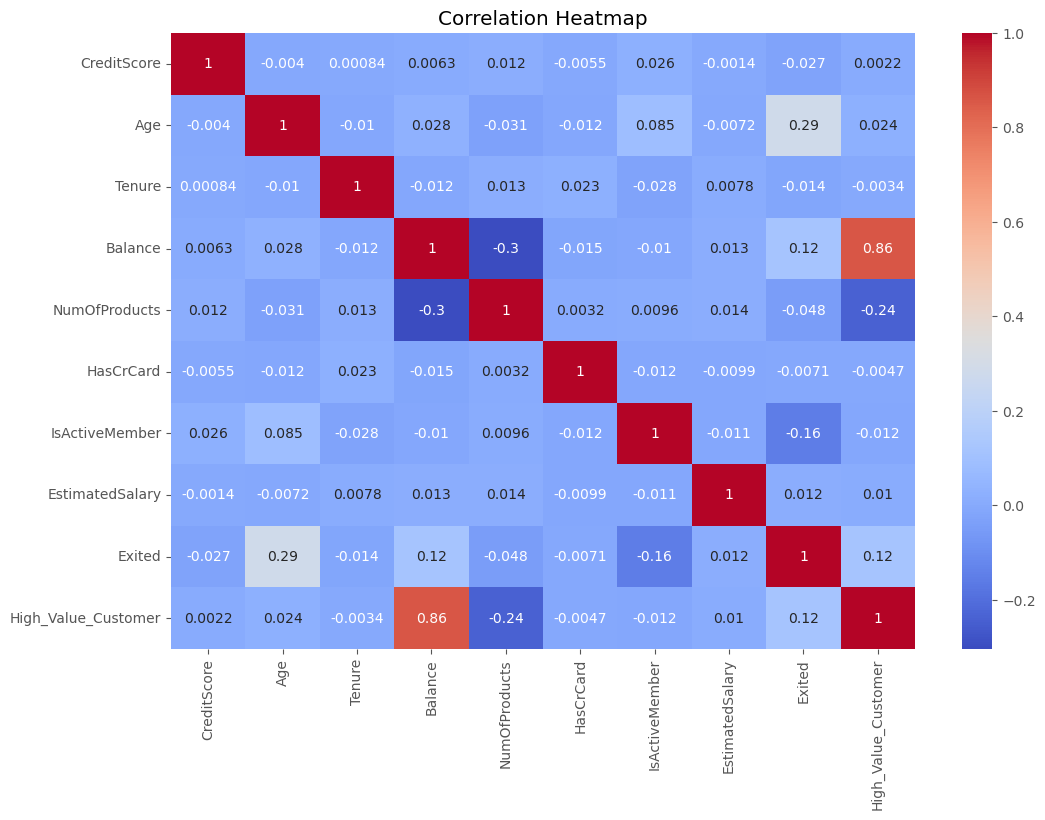

In [120]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

## 30. Revenue Risk from Churn

In [123]:
revenue_risk = df[df['Exited']==1]['Balance'].sum()

print("Revenue Risk :", round(revenue_risk,2))

Revenue Risk : 185588094.63


In [125]:
print("Average Balance of Churned Customers:",
      round(df[df['Exited']==1]['Balance'].mean(),2))

print("Average Salary of Churned Customers:",
      round(df[df['Exited']==1]['EstimatedSalary'].mean(),2))

Average Balance of Churned Customers: 91108.54
Average Salary of Churned Customers: 101465.68


## 31. Executive Summary

In [128]:
print("========== EXECUTIVE SUMMARY ==========")

print("Overall Churn Rate :", overall_churn,"%")

print("\nGeographic Risk")
print(geo_risk)

print("\nHigh Value Customer Churn :", high_value_churn,"%")

print("\nTotal Revenue Risk :", round(revenue_risk,2))

========== EXECUTIVE SUMMARY ==========
Overall Churn Rate : 20.37 %

Geographic Risk
Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64

High Value Customer Churn : 25.23 %

Total Revenue Risk : 185588094.63


## 31B Key Business Insights

In [131]:
print("========== KEY INSIGHTS ==========")

print("1. Germany has the highest churn rate among all countries.")

print("2. Customers aged 46-60 are the most likely to churn.")

print("3. Inactive customers show significantly higher churn.")

print("4. High-value customers have a churn rate above the overall churn rate.")

print("5. Female customers churn more frequently than male customers.")

print("6. Customers with 3 or more products show higher churn risk.")

print("7. Credit score alone is not a strong predictor of churn.")

========== KEY INSIGHTS ==========
1. Germany has the highest churn rate among all countries.
2. Customers aged 46-60 are the most likely to churn.
3. Inactive customers show significantly higher churn.
4. High-value customers have a churn rate above the overall churn rate.
5. Female customers churn more frequently than male customers.
6. Customers with 3 or more products show higher churn risk.
7. Credit score alone is not a strong predictor of churn.


# Checks Before Saving
### Check Missing Values Again

In [134]:
print(df.isnull().sum())

CreditScore            0
Geography              0
Gender                 0
Age                    0
Tenure                 0
Balance                0
NumOfProducts          0
HasCrCard              0
IsActiveMember         0
EstimatedSalary        0
Exited                 0
Age_Group              0
Credit_Band            0
Tenure_Group           0
Balance_Group          0
High_Value_Customer    0
dtype: int64


## Check Dataset Shape

In [137]:
print(df.shape)

(10000, 16)


## Check New Columns

In [140]:
print(df[['Age_Group',
          'Credit_Band',
          'Tenure_Group',
          'Balance_Group',
          'High_Value_Customer']].head())

  Age_Group Credit_Band Tenure_Group Balance_Group  High_Value_Customer
0     30-45      Medium          New  Zero Balance                    0
1     30-45      Medium          New   Low Balance                    0
2     30-45      Medium    Long-Term  High Balance                    1
3     30-45      Medium          New  Zero Balance                    0
4     30-45        High          New  High Balance                    1


## Check Segment Distributions

In [143]:
print(df['Age_Group'].value_counts())

print(df['Credit_Band'].value_counts())

print(df['Tenure_Group'].value_counts())

print(df['Balance_Group'].value_counts())

Age_Group
30-45    5921
<30      1968
46-60    1647
60+       464
Name: count, dtype: int64
Credit_Band
Medium    6241
High      3116
Low        643
Name: count, dtype: int64
Tenure_Group
Mid-Term     3996
New          3505
Long-Term    2499
Name: count, dtype: int64
Balance_Group
High Balance    4799
Zero Balance    3617
Low Balance     1584
Name: count, dtype: int64


## Create Final Clean Dataset

In [146]:
cleaned_df = df.copy()

## Save Cleaned CSV File

In [149]:
cleaned_df.to_csv(
    "European_Bank_Cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Verify Saved File

In [152]:
check_df = pd.read_csv("European_Bank_Cleaned.csv")

print(check_df.shape)

check_df.head()

(10000, 16)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,Credit_Band,Tenure_Group,Balance_Group,High_Value_Customer
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,30-45,Medium,New,Zero Balance,0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,30-45,Medium,New,Low Balance,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,30-45,Medium,Long-Term,High Balance,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30-45,Medium,New,Zero Balance,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,30-45,High,New,High Balance,1


# Additional Analysis
### Churn Contribution by Segment Size

In [155]:
segment_contribution = (
    df.groupby('Age_Group')['Exited']
      .sum()
      .sort_values(ascending=False)
)

print(segment_contribution)

Age_Group
30-45    932
46-60    842
<30      148
60+      115
Name: Exited, dtype: int64


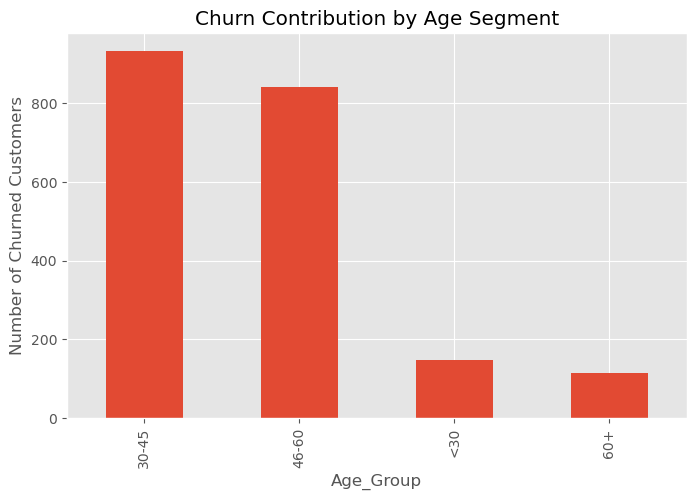

In [157]:
segment_contribution.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Churn Contribution by Age Segment")
plt.ylabel("Number of Churned Customers")
plt.show()

### Financial Stability vs Churn Comparison

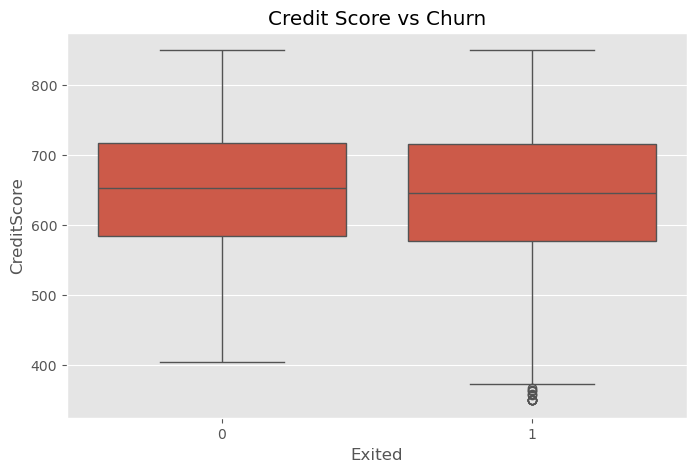

In [160]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='CreditScore',
    data=df
)

plt.title("Credit Score vs Churn")
plt.show()

## Product Usage vs Churn

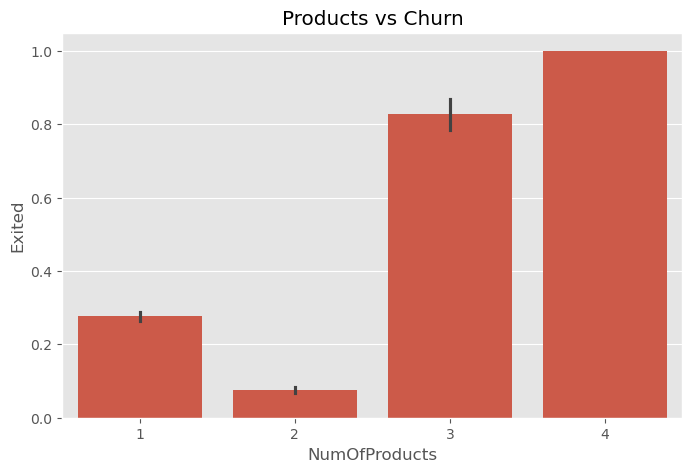

In [163]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='NumOfProducts',
    y='Exited',
    data=df
)

plt.title("Products vs Churn")
plt.show()

## Clean Dataset

In [166]:
cleaned_df.to_csv(
    "European_Bank_Cleaned.csv",
    index=False
)

In [168]:
cleaned_df = df.copy()

cleaned_df.to_csv(
    "European_Bank_Cleaned.csv",
    index=False
)

print("CSV Created Successfully")

CSV Created Successfully
